In [21]:
import pandas as pd
import numpy as np
from sklearn.model_selection import train_test_split
from tensorflow.keras.preprocessing.text import Tokenizer
from tensorflow.keras.preprocessing.sequence import pad_sequences
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Embedding, SimpleRNN, Dense

In [24]:
df = pd.read_csv("C:\\Users\\Lenovo\\Ag News Dataset\\train.csv")
df.head()

,Class Index,Title,Description
0,3,Wall St. Bears Claw Back Into the Black (Reuters),"Reuters - Short-sellers, Wall Street's dwindli..."
1,3,Carlyle Looks Toward Commercial Aerospace (Reu...,Reuters - Private investment firm Carlyle Grou...
2,3,Oil and Economy Cloud Stocks' Outlook (Reuters),Reuters - Soaring crude prices plus worries\ab...
3,3,Iraq Halts Oil Exports from Main Southern Pipe...,Reuters - Authorities have halted oil export\f...
4,3,"Oil prices soar to all-time record, posing new...","AFP - Tearaway world oil prices, toppling reco..."


In [25]:
df["text"] = df["Title"] + " " + df["Description"]
df.head()

,Class Index,Title,Description,text
0,3,Wall St. Bears Claw Back Into the Black (Reuters),"Reuters - Short-sellers, Wall Street's dwindli...",Wall St. Bears Claw Back Into the Black (Reute...
1,3,Carlyle Looks Toward Commercial Aerospace (Reu...,Reuters - Private investment firm Carlyle Grou...,Carlyle Looks Toward Commercial Aerospace (Reu...
2,3,Oil and Economy Cloud Stocks' Outlook (Reuters),Reuters - Soaring crude prices plus worries\ab...,Oil and Economy Cloud Stocks' Outlook (Reuters...
3,3,Iraq Halts Oil Exports from Main Southern Pipe...,Reuters - Authorities have halted oil export\f...,Iraq Halts Oil Exports from Main Southern Pipe...
4,3,"Oil prices soar to all-time record, posing new...","AFP - Tearaway world oil prices, toppling reco...","Oil prices soar to all-time record, posing new..."


In [26]:
X = df["text"]
y = df["Class Index"] - 1

In [27]:
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42
)

In [28]:
tokenizer = Tokenizer(num_words=10000)
tokenizer.fit_on_texts(X_train)
X_train = tokenizer.texts_to_sequences(X_train)
X_test = tokenizer.texts_to_sequences(X_test)

In [29]:
max_length = 100
X_train = pad_sequences(X_train, maxlen=max_length)
X_test = pad_sequences(X_test, maxlen=max_length)

In [30]:
model = Sequential()
model.add(Embedding(input_dim=10000, output_dim=64))
model.add(SimpleRNN(64))
model.add(Dense(4, activation="softmax"))
model.compile(
    optimizer="adam",
    loss="sparse_categorical_crossentropy",
    metrics=["accuracy"]
)
model.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━┓
┃ Layer (type)                         ┃ Output Shape                ┃         Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━┩
│ embedding (Embedding)                │ ?                           │     0 (unbuilt) │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ simple_rnn (SimpleRNN)               │ ?                           │     0 (unbuilt) │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense (Dense)                        │ ?                           │     0 (unbuilt) │
└──────────────────────────────────────┴─────────────────────────────┴─────────────────┘

 Total params: 0 (0.00 B)

 Trainable params: 0 (0.00 B)

 Non-trainable params: 0 (0.00 B)

In [31]:
history = model.fit(
    X_train,
    y_train,
    epochs=5,
    batch_size=64,
    validation_split=0.2
)

Epoch 1/5
1200/1200 ━━━━━━━━━━━━━━━━━━━━ 53s 41ms/step - accuracy: 0.7991 - loss: 0.5268 - val_accuracy: 0.8863 - val_loss: 0.3537
Epoch 2/5
1200/1200 ━━━━━━━━━━━━━━━━━━━━ 47s 39ms/step - accuracy: 0.9083 - loss: 0.2952 - val_accuracy: 0.8981 - val_loss: 0.3353
Epoch 3/5
1200/1200 ━━━━━━━━━━━━━━━━━━━━ 47s 39ms/step - accuracy: 0.9247 - loss: 0.2418 - val_accuracy: 0.8916 - val_loss: 0.3497
Epoch 4/5
1200/1200 ━━━━━━━━━━━━━━━━━━━━ 46s 38ms/step - accuracy: 0.9391 - loss: 0.1910 - val_accuracy: 0.8917 - val_loss: 0.3820
Epoch 5/5
1200/1200 ━━━━━━━━━━━━━━━━━━━━ 47s 39ms/step - accuracy: 0.9585 - loss: 0.1305 - val_accuracy: 0.8749 - val_loss: 0.4300


In [32]:
loss, accuracy = model.evaluate(X_test, y_test)
print("Test Accuracy:", accuracy)

750/750 ━━━━━━━━━━━━━━━━━━━━ 7s 9ms/step - accuracy: 0.8722 - loss: 0.4391
Test Accuracy: 0.8721666932106018


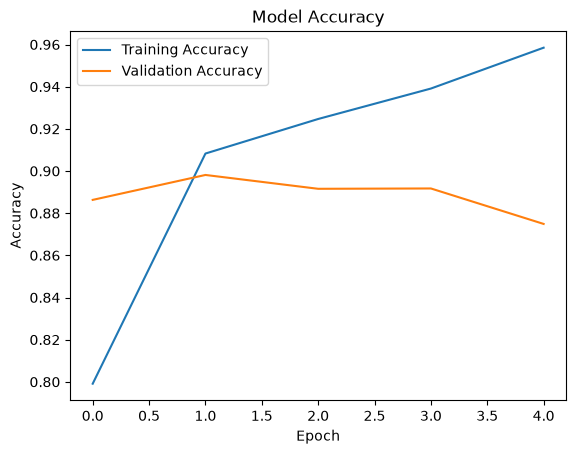

In [33]:
import matplotlib.pyplot as plt
plt.plot(history.history["accuracy"], label="Training Accuracy")
plt.plot(history.history["val_accuracy"], label="Validation Accuracy")
plt.xlabel("Epoch")
plt.ylabel("Accuracy")
plt.title("Model Accuracy")
plt.legend()
plt.show()

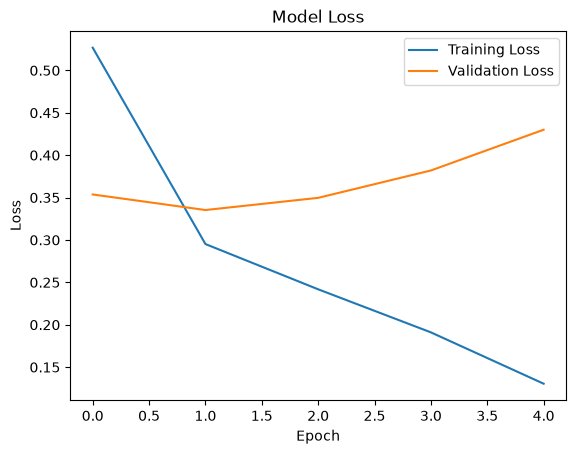

In [34]:
plt.plot(history.history["loss"], label="Training Loss")
plt.plot(history.history["val_loss"], label="Validation Loss")
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.title("Model Loss")
plt.legend()
plt.show()

In [35]:
categories = {
    0: "World",
    1: "Sports",
    2: "Business",
    3: "Science/Technology"
}
text = input("Enter News: ")
seq = tokenizer.texts_to_sequences([text])
pad = pad_sequences(seq, maxlen=max_length)
prediction = model.predict(pad)
index = np.argmax(prediction)
print("Predicted Category:", categories[index])

Enter News:  Wall St. Bears Claw Back Into the Black (Reuters)


1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 325ms/step
Predicted Category: World
